In [94]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [111]:
GRID_SIZE = 5
GAMMA = 0.9

ACTION = [
    (-1,0), (0,1),
    (1,0), (0,-1),
    (0,0)
    ]
ACTION_SYMBOLS = [
    '↑', '→',
    '↓', '←',
    'O'
    ]
GOAL_STATE = (3, 2)

OBSTACLE = [
    (1,1), (1,2),
    (2,2),
    (3,1), (3,3),
    (4,1)
]
THETA=1e-4

obstacle_through = True

Epsilon = 0.0
episode_length = 5000

In [96]:
"""
状态转移函数
"""

def step(state, action_idx, obstacle_through=False):
    """
    返回: next_state, reward
    """
    if state == GOAL_STATE:
        return state, 1.0
    
    r, c = state
    dr, dc = ACTION[action_idx]
    next_r, next_c = r + dr, c + dc

    # 检查边界
    if next_r < 0 or next_r >= GRID_SIZE or next_c < 0 or next_c >= GRID_SIZE:
        return state, -1.0 # 撞墙: 奖励-1，留在原地
    
    next_state = (next_r, next_c)

    # 检查障碍物
    if obstacle_through:
        if next_state in OBSTACLE:
            return next_state, -10.0
    else:
        if next_state in OBSTACLE:
            return state, -10.0 # 撞障碍物: 奖励-10，留在原地; 如果允许穿过障碍物，则为返回next_state
    
    # 正常状态转移
    if next_state == GOAL_STATE:
        return next_state, 1.0 # 到达目标状态: 奖励1
    else:
        return next_state, -0.1

"""
提取最优策略 (Policy Extraction)
"""
def extract_policy(GRID_SIZE, OBSTACLE, Q_final, obstacle_through=True):
    final_policy = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
    final_V = np.zeros((GRID_SIZE, GRID_SIZE))
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            state = (i, j)
            
            if (i, j) in OBSTACLE and not obstacle_through:
                continue 
            
            # 提取最大 Q 值对应的动作 (argmax)
            final_policy[i, j] = np.argmax(Q_final[i, j])
            # 提取最大 Q 值作为该格子的状态价值 V(s) (max)
            final_V[i, j] = np.max(Q_final[i, j])
    
    return final_policy, final_V
    

In [97]:
"""
Monte Carlo episode generation & Action Selection
"""
def get_epsilon_greedy_action(q_values_for_state, epsilon):
    """
    根据给定的 Q 值表和 epsilon 生成随机episode
    """
    if np.random.rand() < epsilon:
        # 探索，纯随机选择一个动作
        # epsilon 的值越大，探索的概率越高；当 epsilon=1 时，完全随机选择动作
        return np.random.randint(len(q_values_for_state))
    else:
        # 非探索：选择 Q 值最高的动作
        # 如果有多个动作具有相同的最高 Q 值，np.argmax 会返回第一个出现的索引
        return np.argmax(q_values_for_state)
    
def generate_episode(Q, epsilon, GRID_SIZE, GOAL_STATE, max_steps=100, obstacle_through=True):
    """
    跑出episode, 返回轨迹 [(state, action, reward), ...]
    """
    trajectory = []

    # 随机初始化一个起点
    while True:
        r = np.random.randint(GRID_SIZE)
        c = np.random.randint(GRID_SIZE)
        state = (r, c)
        if state == GOAL_STATE:
            continue
        # 如果不允许穿透，且随机到了障碍物里，重新随机
        if not obstacle_through and state in OBSTACLE:
            continue
            
        break # 找到合法出生点，跳出循环
    
    for t in range(max_steps):
        r, c = state
        # 实现 Exploring Starts: episode 的起点是随机的
        if t == 0:
            # 不管epsilon的值，第一步都随机选择一个动作
            action = np.random.randint(len(ACTION))
        else:
            # 第二步开始，根据 epsilon-greedy 策略选择动作
            action = get_epsilon_greedy_action(Q[r, c], epsilon)
            
       
        # 执行动作，获取下一个状态和奖励
        next_state, reward = step(state, action, obstacle_through=obstacle_through)
        # 记录轨迹
        trajectory.append((state, action, reward))

        if next_state == GOAL_STATE:
            break

        state = next_state
    
    return trajectory





In [105]:
"""
Monte Carlo Epsilon-greedy policy evaluation
采用的是every_visit, GPI (广义策略迭代), 每个episode结束后, 直接更新Q值表, 而不是先评估V函数再提取策略。
"""

def mc_epsilon_greedy_control(Q, epsilon, num_episodes, GRID_SIZE, GOAL_STATE, ACTION, GAMMA, obstacle_through=True):
    
    # 初始化 N 表示每个状态-动作对被访问的次数
    N = np.zeros((GRID_SIZE, GRID_SIZE, len(ACTION)), dtype=int)
    # 记录每个状态-动作对的回报历史
    return_history = []

    # 靠num_episodes控制迭代次数，越大越接近最优策略，但计算时间也越长
    for ep in range(num_episodes):
        # 生成一个episode
        trajectory = generate_episode(Q, epsilon, GRID_SIZE, GOAL_STATE, obstacle_through=obstacle_through)

        # 计算并记录这一次episo的总得分 (不打折的纯Reward之和)
        episode_total_reward = sum([step_data[2] for step_data in trajectory])
        return_history.append(episode_total_reward)

        G = 0
        # 从后往前计算回报，并更新Q值
        for i in reversed(range(len(trajectory))):
            state, action, reward = trajectory[i]
            r, c = state

            # 更新回报, G_t = R_{t+1} + gamma * G_{t+1}
            G = reward + GAMMA * G

            # 每次路过，该状态-动作对的访问次数加1
            N[r, c, action] += 1

            current_q = Q[r, c, action]
            # step_size = 1.0 / N[r, c, action]
            step_size = 0.1
            # 倒叙做法的话，公式要对应转变为 Q_N = Q_{N-1} + (1/N) * (G - Q_{N-1})
            Q[r, c, action] = current_q + step_size * (G - current_q)
    
    return Q, return_history


In [106]:
"""
可视化 (Heatmap & Policy Arrows)
"""
def visualize_grid(V, policy, Epsilon, OBSTACLE, obstacle_through=False):
    plt.figure(figsize=(8, 6))
    
    V_plot = np.copy(V)
    # 只有在不允许穿透时，才把障碍物设为 NaN 挖空（显示为背景色）
    # 如果允许穿透，我们要保留它惨烈的负分，让热力图显示出来
    if not obstacle_through:
        for (r, c) in OBSTACLE:
            V_plot[r, c] = np.nan
        
    ax = sns.heatmap(V_plot, annot=True, fmt=".2f", cmap="YlGnBu", 
                     linewidths=.5, cbar_kws={'label': 'State Value $V(s)$'})
    
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            state = (i, j)
            
            if not obstacle_through and state in OBSTACLE:
                # 不可穿透的墙，画上灰色大方块
                ax.text(j + 0.5, i + 0.5, '██', ha='center', va='center', color='gray', fontsize=20)
            
            elif state == GOAL_STATE:
                # 终点
                symbol = ACTION_SYMBOLS[policy[i, j]]
                ax.text(j + 0.5, i + 0.8, f"GOAL({symbol})", ha='center', va='center', color='red', weight='bold')
            
            else:
                symbol = ACTION_SYMBOLS[policy[i, j]]
                
                # 如果允许穿透，给障碍物格子加上特殊的色和紫色箭头
                if obstacle_through and state in OBSTACLE:
                    ax.text(j + 0.5, i + 0.8, symbol, ha='center', va='center', color='purple', fontsize=18, weight='bold')
                    ax.text(j + 0.5, i + 0.5, '██', ha='center', va='center', color='red', alpha=0.3, fontsize=20)
                else:
                    # 正常平地
                    ax.text(j + 0.5, i + 0.8, symbol, ha='center', va='center', color='black', fontsize=16, weight='bold')
                
    plt.title(f"MC Control ($\gamma$={GAMMA}, $\epsilon$={Epsilon}) | Obstacle Through: {obstacle_through}")
    plt.show()

def plot_learning_curve(learning_curve, window_size=100):
    """
    繪製學習曲線，包含原始回報和滑動平均回報
    """
    plt.figure(figsize=(10, 6))
    
    # 1. 繪製原始數據 (淺藍色，透明度低，用於觀察波動範圍)
    plt.plot(learning_curve, color='blue', alpha=0.2, label='Raw Total Reward')
    
    # 2. 計算並繪製滑動平均線 (紅色，較粗，用於觀察收斂趨勢)
    # 只有當 episode 數量大於窗口大小時才計算
    if len(learning_curve) >= window_size:
        # 使用 np.convolve 快速計算滑動平均
        moving_avg = np.convolve(learning_curve, np.ones(window_size)/window_size, mode='valid')
        # x 軸需要對齊，因為 valid 模式會砍掉前面的 window_size - 1 個點
        x_axis = np.arange(window_size - 1, len(learning_curve))
        plt.plot(x_axis, moving_avg, color='red', linewidth=2.5, label=f'Moving Average (window={window_size})')
        
    plt.title('Monte Carlo Control Learning Curve', fontsize=16)
    plt.xlabel('Episode', fontsize=14)
    plt.ylabel('Total Reward per Episode', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()



In [112]:
Q_init = np.zeros((GRID_SIZE, GRID_SIZE, len(ACTION)))
Q_final, learning_curve = mc_epsilon_greedy_control(
    Q_init, epsilon=Epsilon, num_episodes=5000, 
    GRID_SIZE=GRID_SIZE, GOAL_STATE=GOAL_STATE, 
    ACTION=ACTION, GAMMA=GAMMA, 
    obstacle_through=obstacle_through
)

In [113]:
final_policy, final_V = extract_policy(GRID_SIZE, OBSTACLE, Q_final, obstacle_through=obstacle_through)
final_policy, final_V

(array([[1, 1, 1, 1, 2],
        [0, 3, 1, 1, 2],
        [0, 3, 2, 1, 2],
        [0, 1, 0, 3, 2],
        [0, 1, 0, 3, 3]]),
 array([[-0.30264312, -0.22515902, -0.13906558, -0.0434062 ,  0.062882  ],
        [-0.37237881, -0.43514093, -0.04340748,  0.062882  ,  0.18098   ],
        [-0.43514093, -0.49162684,  1.        ,  0.18098   ,  0.3122    ],
        [-0.49162683,  1.        ,  0.        ,  0.99999997,  0.458     ],
        [-0.54246417,  0.8       ,  1.        ,  0.8       ,  0.62      ]]))

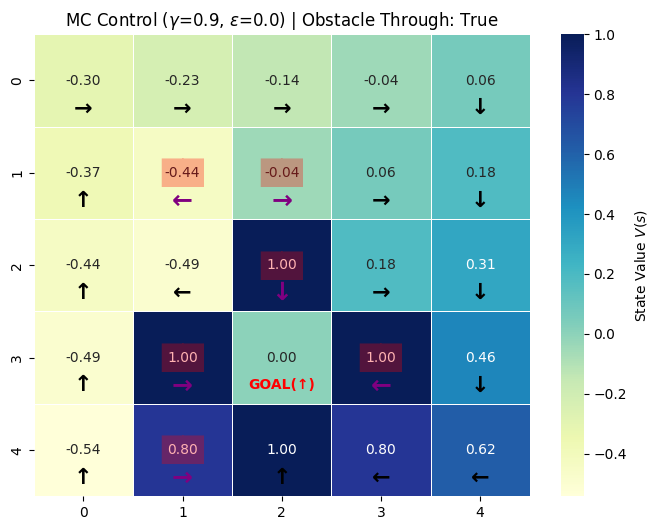

In [114]:
visualize_grid(final_V, final_policy, Epsilon, OBSTACLE, obstacle_through=obstacle_through)

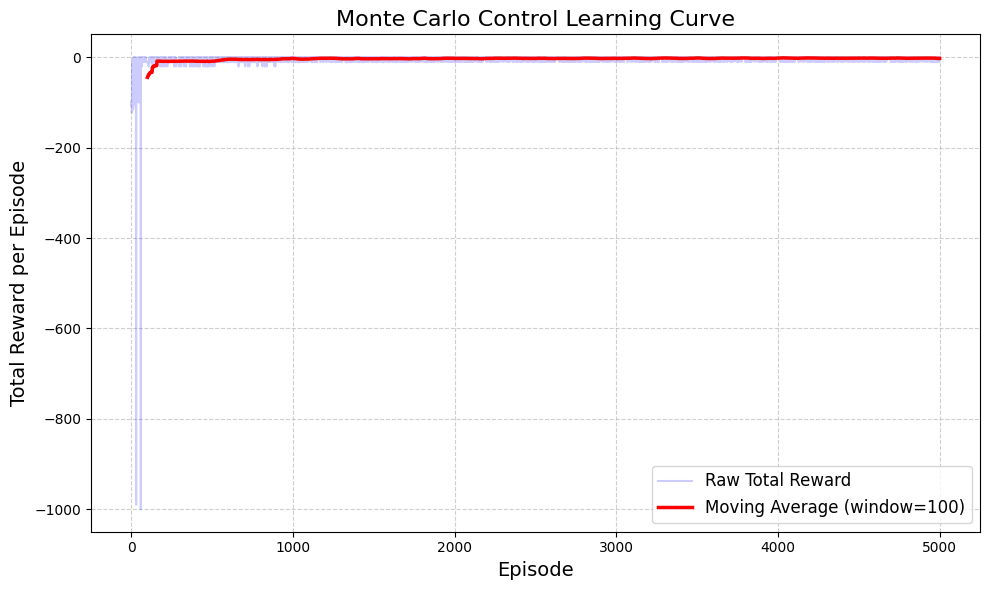

In [115]:
plot_learning_curve(learning_curve, window_size=100)

In [116]:
# 考虑动态的epsilon，开始时用较大的epsilon进行大范围探索，较小的epsilon帮助收敛